## Project Structure

1. Import Libraries
2. Load Dataset
3. Data Exploration
4. Data Cleaning & Preprocessing
5. Feature Engineering
6. Linear Regression Model
7. Random Forest Regressor
8. Model Evaluation
9. Visualizations
10. Insights & Business Recommendations

Import Libraries


In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

Load Dataset

In [2]:
df = pd.read_csv("Housing.csv")

Data Exploration

In [4]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [5]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 545
Columns : 13


In [6]:
print(df.columns)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [7]:
target = 'price'

features = df.drop(columns=['price']).columns

print("Target Variable :", target)
print("Features:")
print(features)

Target Variable : price
Features:
Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')


In [8]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


Data Cleaning and Preprocessing

In [9]:
df = df.dropna()

In [10]:
print("Duplicates:", df.duplicated().sum())

df = df.drop_duplicates()

print("Shape After Removing Duplicates:", df.shape)

Duplicates: 0
Shape After Removing Duplicates: (545, 13)


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [12]:
df = pd.get_dummies(
    df,
    drop_first=True
)

In [13]:
df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   parking                          545 non-null    int64
 6   mainroad_yes                     545 non-null    bool 
 7   guestroom_yes                    545 non-null    bool 
 8   basement_yes                     545 non-null    bool 
 9   hotwaterheating_yes              545 non-null    bool 
 10  airconditioning_yes              545 non-null    bool 
 11  prefarea_yes                     545 non-null    bool 
 12  furnishingstatus_semi-furnished  545 non-null    b

Feature Engineering

In [15]:
X = df.drop("price", axis=1)

y = df["price"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

Linear Regression Model

In [17]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

LinearRegression()

In [18]:
lr_predictions = lr_model.predict(X_test)

In [19]:
lr_mae = mean_absolute_error(
    y_test,
    lr_predictions
)

lr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lr_predictions
    )
)

lr_r2 = r2_score(
    y_test,
    lr_predictions
)

print("Linear Regression Results")
print("MAE :", lr_mae)
print("RMSE :", lr_rmse)
print("R² :", lr_r2)

Linear Regression Results
MAE : 970043.403920164
RMSE : 1324506.9600914384
R² : 0.6529242642153186


Random Forest Regressor

In [34]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [35]:
rf_predictions = rf_model.predict(X_test)

In [36]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest Results")
print("MAE :", rf_mae)
print("RMSE :", rf_rmse)
print("R² :", rf_r2)

Random Forest Results
MAE : 1013968.579587156
RMSE : 1398115.6668385956
R² : 0.6132752494107068


Model Evaluation

In [23]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R2 Score": [lr_r2, rf_r2]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.013969e+06,1.398116e+06,0.613275


Feature Importance

In [38]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
  )

feature_importance.head(10)

,Feature,Importance
0,area,0.468535
2,bathrooms,0.152554
9,airconditioning_yes,0.060238
4,parking,0.057273
3,stories,0.057064
1,bedrooms,0.047370
12,furnishingstatus_unfurnished,0.036972
7,basement_yes,0.032176
10,prefarea_yes,0.028432
8,hotwaterheating_yes,0.018305


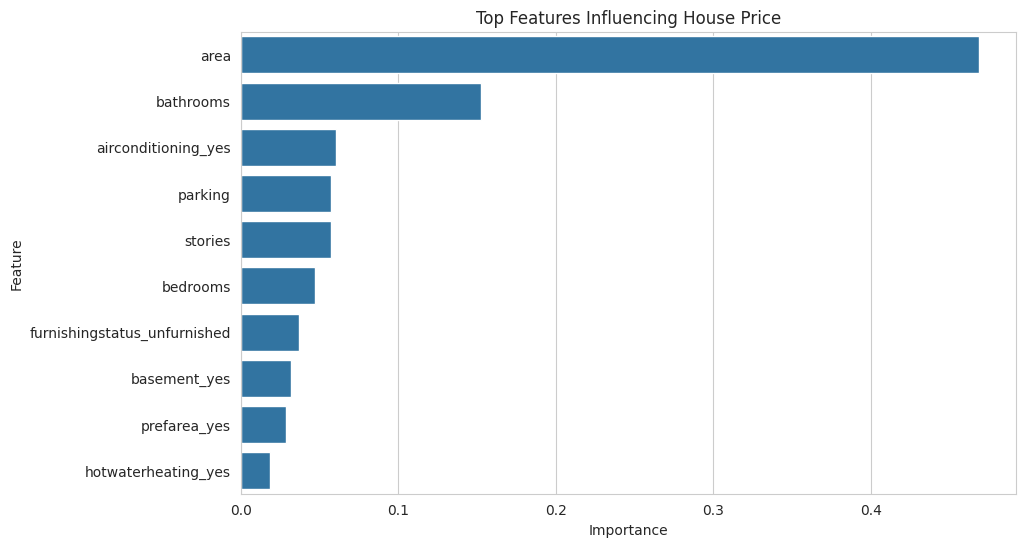

In [39]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top Features Influencing House Price")
plt.show()

Visualizarions

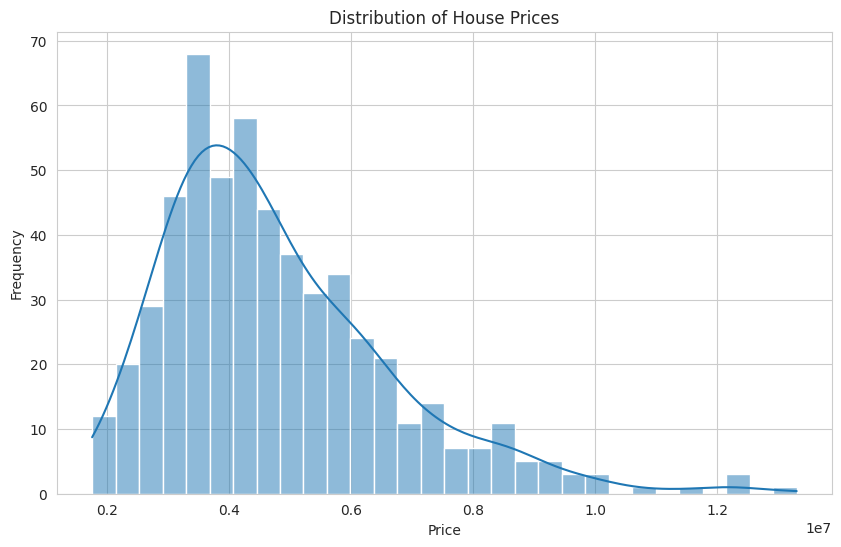

In [40]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["price"],
    bins=30,
    kde=True
)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

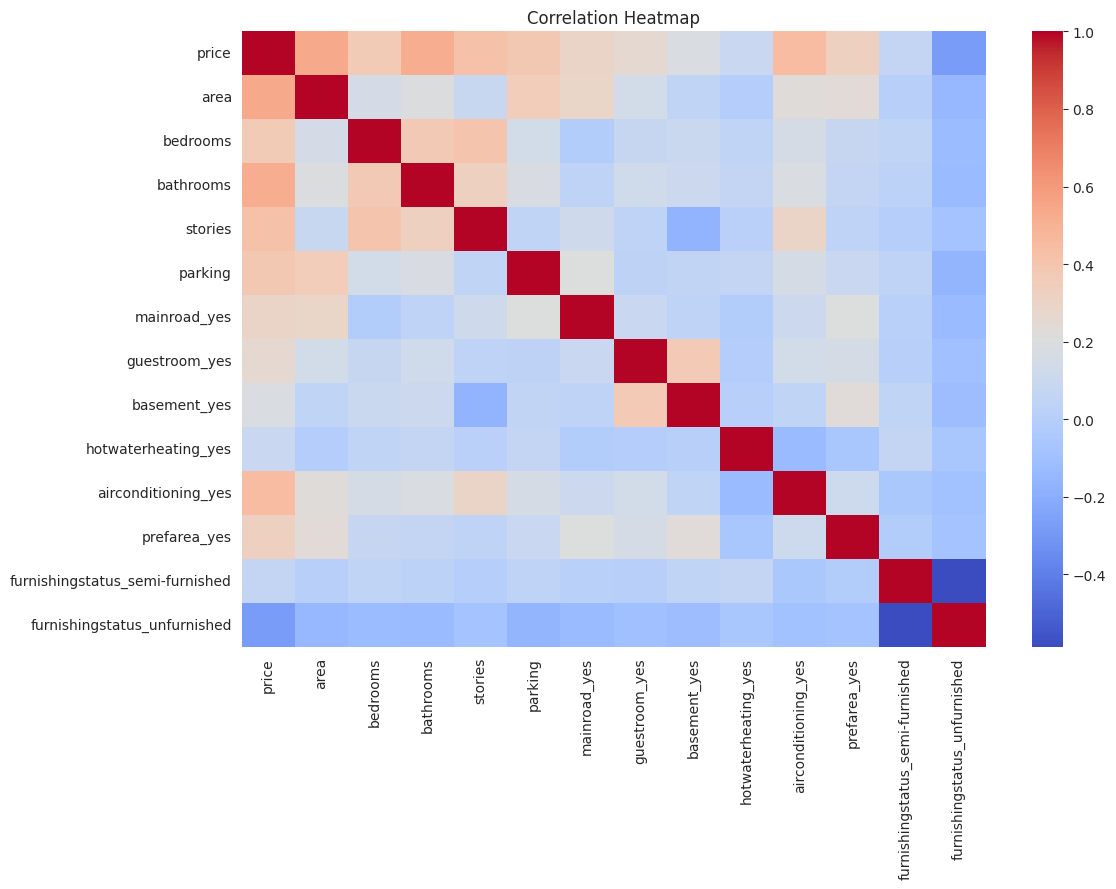

In [41]:
plt.figure(figsize=(12,8))

corr = df.corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")
plt.show()

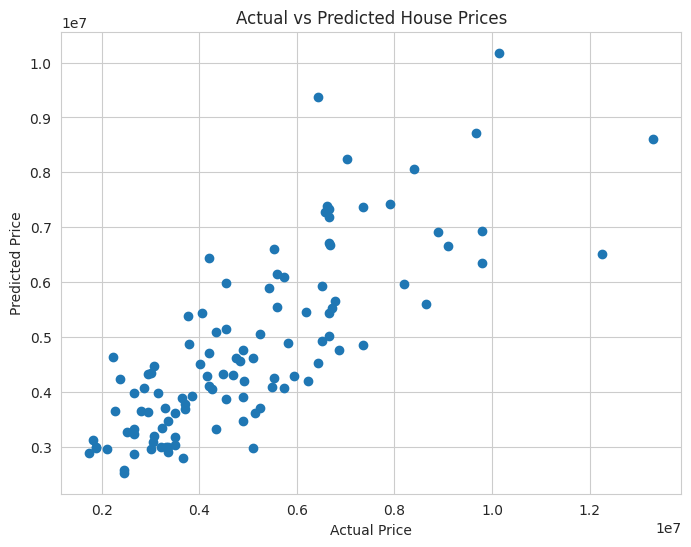

In [42]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    rf_predictions
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.show()

Price vs Area

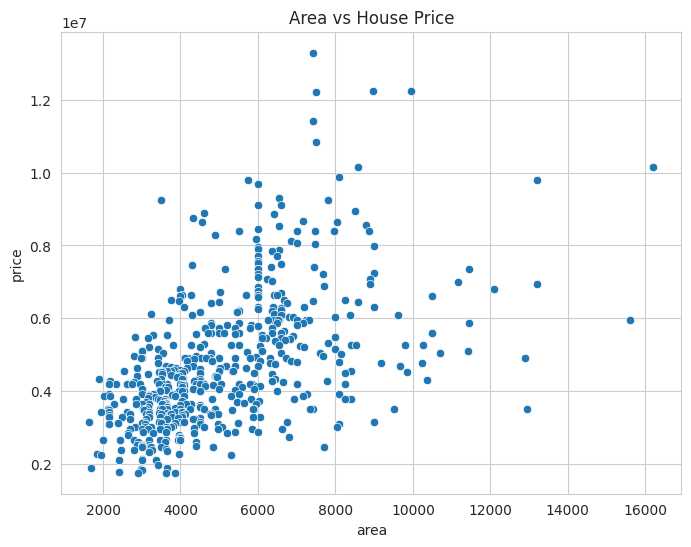

In [43]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="area",
    y="price"
)

plt.title("Area vs House Price")

plt.show()

Importance Statistical Analysis

In [44]:
price_corr = (
    df.corr()['price']
    .sort_values(ascending=False)
)

print(price_corr)

price                              1.000000
area                               0.535997
bathrooms                          0.517545
airconditioning_yes                0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea_yes                       0.329777
mainroad_yes                       0.296898
guestroom_yes                      0.255517
basement_yes                       0.187057
hotwaterheating_yes                0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64


## Insights and Business Recommendations

Q : Which features influence house price the most?

- The model identified area, number of bathrooms, air conditioning, parking availability, and preferred area location as the strongest factors influencing house prices.

Q :  How accurate was your model (in plain terms)?



- Among the two models tested, the Linear Regression Regressor performed better, achieving a higher R² score and lower prediction error compared to Random Forest Regressor.
- This indicates that house prices are influenced by several non-linear relationships that Linear Regression can capture more effectively.

Q : What surprised you in the data?

- One surprising finding was that some amenities, such as guest rooms and hot water heating, contributed less to price than expected. The data also showed that location-related features had a significant impact on pricing.

Q : One recommendation for a real estate business based on your findings

- Based on these findings, real estate businesses should focus marketing efforts on larger homes in preferred areas with modern amenities, as these characteristics consistently command higher prices.